In [1]:
pip install numpy matplotlib scikit-learn opencv-python

In [2]:
import numpy as np

def lagrangepoly(X, Y):
    """
    Lagrange interpolation polynomial fitting a set of points.
    Returns the coefficients P, the roots of the derivative R,
    and the evaluated Y values at those roots S.
    """
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    N = len(X)

    pvals = np.zeros((N, N))

    for i in range(N):
        # Create array of all X values except X[i]
        X_ex = np.concatenate((X[:i], X[i+1:]))
        pp = np.poly(X_ex)
        # Scale so value is exactly 1 at X[i]
        pvals[i, :] = pp / np.polyval(pp, X[i])

    P = np.dot(Y, pvals)

    # Calculate roots of the derivative (extrema)
    dP = np.polyder(P)
    R = np.roots(dP)

    # Calculate actual values at points of zero derivative
    S = np.polyval(P, R)

    return P, R, S

In [3]:
import numpy as np

def slht(s, idx, n, m, nk):
    """
    Calculates the Silhouette values for each cluster and the Global Silhouette index.
    """
    S_const = np.zeros(nk)

    # Sum up individual silhouette values for data points in each cluster
    for r in range(n):
        S_const[idx[r]] += s[r]

    S = np.zeros(nk)
    for j in range(nk):
        if m[j] != 0:
            S[j] = (1.0 / m[j]) * S_const[j]

    # Calculate Global Silhouette value
    GS = (1.0 / nk) * np.sum(S)

    return S, GS

In [4]:
import numpy as np

def soc(x, nk, factor):
    """
    Implements the Improved Mountain Clustering Technique (IMC)
    used for SOC. Accepts an array of factors for threshold calculation.
    """
    n, k_dim = x.shape

    # Normalize each dimension of hyperspace
    x_min = np.min(x, axis=0)
    x_max = np.max(x, axis=0)
    z = x_max - x_min

    u = np.zeros((n, k_dim))
    for j in range(n):
        y = x[j, :] - x_min
        # Handle division by zero
        u[j, :] = np.divide(y, z, out=np.zeros_like(y), where=z!=0)

    U = u.copy()

    m = np.zeros(nk, dtype=int)
    t = np.zeros(nk + 1, dtype=int)
    t[0] = n

    sl = np.zeros((n, nk + 1), dtype=int)
    sl[:, 0] = np.arange(n)

    d1 = np.zeros(nk)
    P = np.zeros((n, nk))
    cc_norm = np.zeros((nk, k_dim))

    SL = np.zeros((n, nk), dtype=int) - 1  # -1 indicates empty
    clst = np.zeros((n, k_dim, nk))
    c_disp = np.zeros((n, k_dim, nk + 1)) + 255

    for v in range(nk):
        if t[v] != 0:
            d_val = 0.0
            for j in range(t[v]):
                row_sum = np.sum(x[sl[j, v], :])
                if row_sum != 0:
                    d_val += np.min(x[sl[j, v], :]) / row_sum

            # Use array factor indexing
            d1[v] = ((1.0 / (2.0 * t[v])) * d_val) * factor[v]

            # Calculate potential value using mountain function
            for r in range(t[v]):
                idx_r = sl[r, v]
                diffs = u[idx_r, :] - u[sl[:t[v], v], :]
                dist_sq = np.sum(diffs**2, axis=1)
                P[r, v] = np.sum(np.exp(-dist_sq / (d1[v]**2)))

            # Select cluster center
            zmax = np.argmax(P[:t[v], v])
            cc_norm[v, :] = u[sl[zmax, v], :]

            # Assign points to cluster
            t_next = 0
            for r in range(t[v]):
                idx_r = sl[r, v]
                dist = np.sum((u[idx_r, :] - cc_norm[v, :])**2)

                if dist <= d1[v]:
                    SL[m[v], v] = idx_r
                    clst[m[v], :, v] = x[idx_r, :]
                    c_disp[idx_r, :, v] = x[idx_r, :]
                    m[v] += 1
                else:
                    sl[t_next, v + 1] = idx_r
                    c_disp[idx_r, :, v] = 255
                    t_next += 1
            t[v + 1] = t_next

    # Distribute left out data points
    if t[nk] != 0:
        for r_idx in range(t[nk]):
            idx_r = sl[r_idx, nk]
            diffs = U[idx_r, :] - cc_norm
            D = np.sum(diffs**2, axis=1)
            v_min = np.argmin(D)

            SL[m[v_min], v_min] = idx_r
            clst[m[v_min], :, v_min] = x[idx_r, :]
            c_disp[idx_r, :, v_min] = x[idx_r, :]
            m[v_min] += 1

    # Calculate idx labels and distances
    idx = np.zeros(n, dtype=int)
    dd = np.zeros((n, nk))

    for r in range(n):
        for v in range(nk):
            if m[v] != 0:
                dd[r, v] = np.sum((U[r, :] - cc_norm[v, :])**2)
                if r in SL[:m[v], v]:
                    idx[r] = v

    # Partition matrix
    part = np.zeros((n, nk))
    for j in range(n):
        label_min = np.argmin(dd[j, :])
        part[j, label_min] = 1

    return {
        'dd': dd, 'part': part, 'cc_norm': cc_norm,
        'idx': idx, 'c_disp': c_disp, 'clst': clst,
        'm': m, 'SL': SL, 'n': n, 'd1': d1
    }

In [5]:
import numpy as np

def imc2(x, nk, factor):
    """
    Improved Mountain Clustering Technique (IMC) implementation.
    Accepts a single scalar factor.
    """
    n, k_dim = x.shape
    x_min = np.min(x, axis=0)
    x_max = np.max(x, axis=0)
    z = x_max - x_min

    u = np.zeros((n, k_dim))
    for j in range(n):
        y = x[j, :] - x_min
        u[j, :] = np.divide(y, z, out=np.zeros_like(y), where=z!=0)

    U = u.copy()
    m = np.zeros(nk, dtype=int)
    t = np.zeros(nk + 1, dtype=int)
    t[0] = n

    sl = np.zeros((n, nk + 1), dtype=int)
    sl[:, 0] = np.arange(n)

    d1 = np.zeros(nk)
    P = np.zeros((n, nk))
    cc_norm = np.zeros((nk, k_dim))

    SL = np.zeros((n, nk), dtype=int) - 1
    clst = np.zeros((n, k_dim, nk))
    c_disp = np.zeros((n, k_dim, nk + 1)) + 255

    for v in range(nk):
        if t[v] != 0:
            d_val = 0.0
            for j in range(t[v]):
                row_sum = np.sum(x[sl[j, v], :])
                if row_sum != 0:
                    d_val += np.min(x[sl[j, v], :]) / row_sum

            # Apply scalar factor
            d1[v] = ((1.0 / (2.0 * t[v])) * d_val) * factor

            for r in range(t[v]):
                idx_r = sl[r, v]
                diffs = u[idx_r, :] - u[sl[:t[v], v], :]
                dist_sq = np.sum(diffs**2, axis=1)
                P[r, v] = np.sum(np.exp(-dist_sq / (d1[v]**2)))

            zmax = np.argmax(P[:t[v], v])
            cc_norm[v, :] = u[sl[zmax, v], :]

            t_next = 0
            for r in range(t[v]):
                idx_r = sl[r, v]
                dist = np.sum((u[idx_r, :] - cc_norm[v, :])**2)

                if dist <= d1[v]:
                    SL[m[v], v] = idx_r
                    clst[m[v], :, v] = x[idx_r, :]
                    c_disp[idx_r, :, v] = x[idx_r, :]
                    m[v] += 1
                else:
                    sl[t_next, v + 1] = idx_r
                    c_disp[idx_r, :, v] = 255
                    t_next += 1
            t[v + 1] = t_next

    if t[nk] != 0:
        for r_idx in range(t[nk]):
            idx_r = sl[r_idx, nk]
            diffs = U[idx_r, :] - cc_norm
            D = np.sum(diffs**2, axis=1)
            v_min = np.argmin(D)

            SL[m[v_min], v_min] = idx_r
            clst[m[v_min], :, v_min] = x[idx_r, :]
            c_disp[idx_r, :, v_min] = x[idx_r, :]
            m[v_min] += 1

    idx = np.zeros(n, dtype=int)
    dd = np.zeros((n, nk))

    for r in range(n):
        for v in range(nk):
            if m[v] != 0:
                dd[r, v] = np.sum((U[r, :] - cc_norm[v, :])**2)
                if r in SL[:m[v], v]:
                    idx[r] = v

    part = np.zeros((n, nk))
    for j in range(n):
        label_min = np.argmin(dd[j, :])
        part[j, label_min] = 1

    return {
        'dd': dd, 'part': part, 'cc_norm': cc_norm,
        'idx': idx, 'c_disp': c_disp, 'clst': clst,
        'm': m, 'SL': SL, 'n': n, 'd1': d1
    }

In [6]:
import numpy as np
from sklearn.metrics import silhouette_samples

def factorcal(x, nk, iter_max=10):
    """
    Computes the optimization factor via Lagrange interpolation.
    """
    flag = 0
    factor = np.ones((10, nk))
    GS = np.zeros(10)

    for iter_idx in range(iter_max):
        print(f"Optimizing Iteration: {iter_idx+1}/{iter_max}")
        result = soc(x, nk, factor[iter_idx, :])

        # Break if any cluster is empty
        if np.min(result['m']) == 0:
            flag = 1
            break

        # Break if threshold distances duplicate
        for g in range(nk - 1):
            for gg in range(g + 1, nk):
                if result['d1'][g] == result['d1'][gg]:
                    flag = 1

        if flag == 1:
            break

        # Calculate silhouette values using sklearn
        # silhouette_samples expects 2D data and labels
        s = silhouette_samples(x, result['idx'])
        S, GS[iter_idx] = slht(s, result['idx'], result['n'], result['m'], nk)

        # Fit Lagrange polynomial
        P, r, _ = lagrangepoly(result['d1'], S)

        polym = P.copy()
        # Equivalent to polym(1,nk)=polym(1,nk)-1 in MATLAB
        polym[-1] = polym[-1] - 1
        r_roots = np.roots(polym)

        sumn = np.zeros_like(r_roots, dtype=complex)
        for i in range(len(r_roots)):
            for j in range(nk):
                sumn[i] += polym[nk - 1 - j] * (r_roots[i]**j)

        label = np.argmin(np.abs(sumn))
        dmax = np.abs(r_roots[label])

        if iter_idx + 1 < 10:
            factor[iter_idx + 1, :] = dmax / result['d1']

    # Find max Global Silhouette to assign final factor
    if flag == 1 and iter_idx > 0:
        label_max = np.argmax(GS[:iter_idx])
    else:
        label_max = np.argmax(GS[:iter_idx + 1])

    fac = factor[label_max, :]
    return fac


In [7]:
import cv2
import numpy as np
import requests

def load_image_from_url(url):
    """Fetches an image from a URL and returns an RGB numpy array."""
    # 1. Fetch the raw bytes from the URL
    response = requests.get(url)
    response.raise_for_status()  # Throws an error if the URL is broken

    # 2. Convert raw bytes to a 1D numpy array
    image_array = np.asarray(bytearray(response.content), dtype=np.uint8)

    # 3. Decode the 1D array into an OpenCV image matrix (BGR format)
    img_bgr = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    # 4. Convert BGR to RGB for our clustering algorithm
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    return img_rgb

Enter image URL: https://digitalhub.fifa.com/transform/b2dee0e4-3bf3-48fb-92ef-7cc786c034ac/Klaas-Jan-Huntelaar-of-the-Netherlands-celebrates-scoring-against-Mexico-at-Brazil-2014-by-performing-a-karate-kick-on-the-corner-flag?focuspoint=0.57,0.08&io=transform:fill,height:910,width:1536&quality=75
No. of clusters required: 5
Running SOC...
Optimizing Iteration: 1/10
Optimizing Iteration: 2/10
Optimizing Iteration: 3/10
Optimizing Iteration: 4/10
Optimizing Iteration: 5/10
Optimizing Iteration: 6/10
Optimizing Iteration: 7/10
Optimizing Iteration: 8/10
Optimizing Iteration: 9/10
Optimizing Iteration: 10/10
Running IMC1...
Running IMC2...
Calculating metrics...
GSS (SOC): 0.42887937305452734
GSI1 (IMC1): 0.35571003475988827
GSI2 (IMC2): 0.2945695191254972


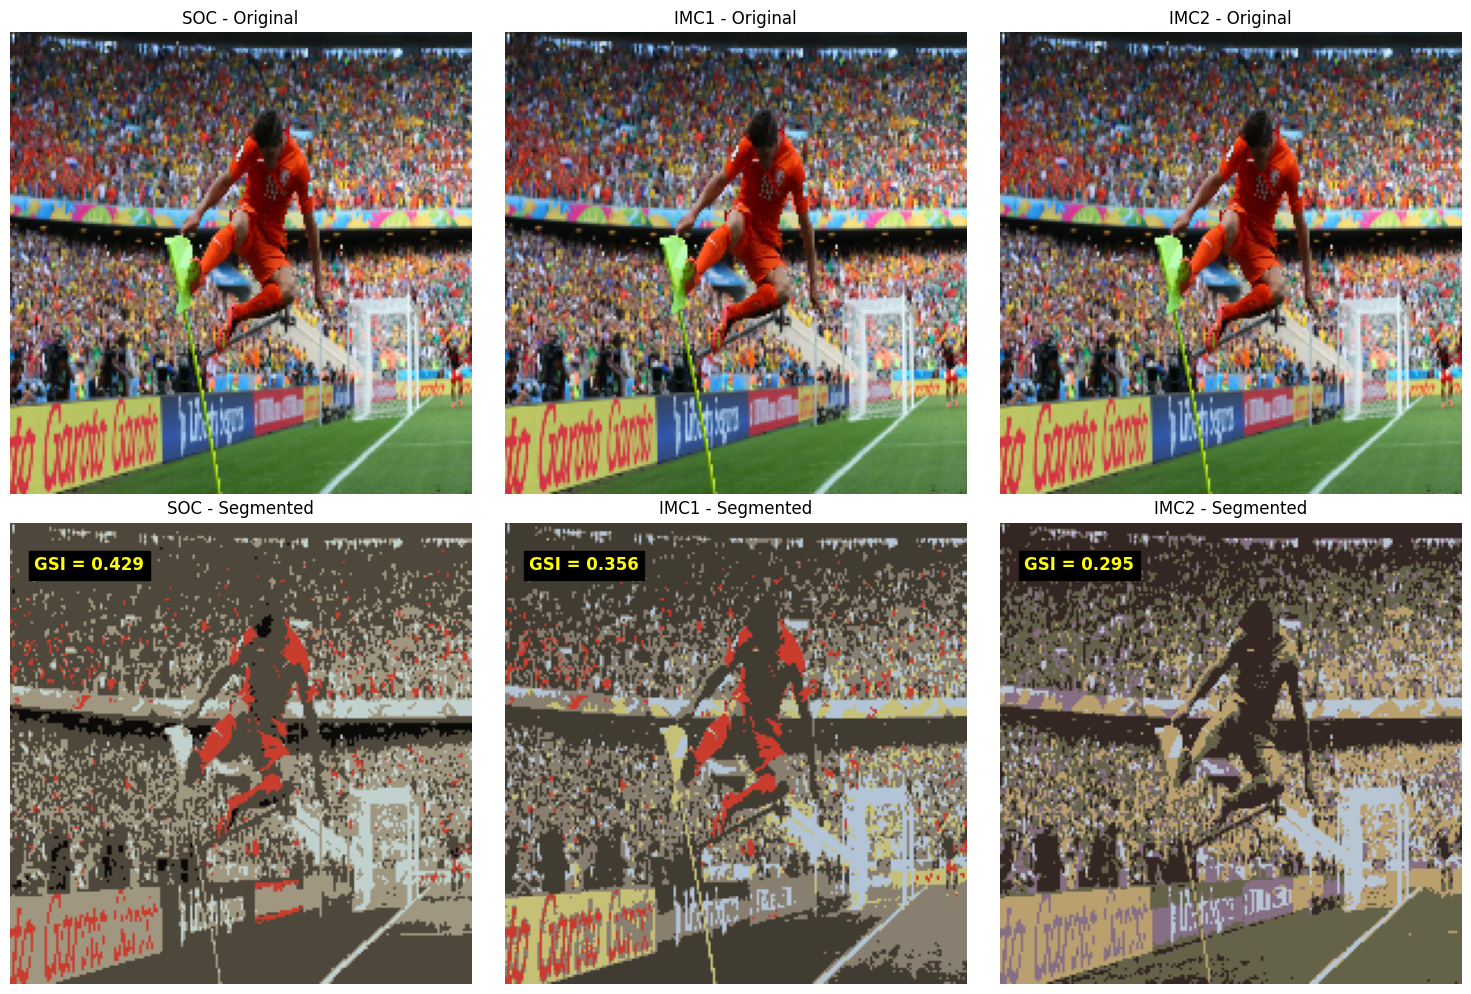

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests  # <-- Make sure this is imported!
from sklearn.metrics import silhouette_samples


def load_image_from_url(url):
    """Fetches an image from a URL and returns an RGB numpy array."""
    response = requests.get(url)
    response.raise_for_status()

    image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
    img_bgr = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    return img_rgb

def main():
    # Ask for a URL instead of a local file path
    image_url = input("Enter image URL: ")
    try:
        # We use the new URL loader here, completely removing cv2.imread
        a = load_image_from_url(image_url)
        a = cv2.resize(a, (200, 200))
    except Exception as e:
        print(f"Error loading image from URL: {e}")
        return

    f, h, k = a.shape
    nk = int(input("No. of clusters required: "))
    n = f * h

    # Reshape image to (n x 3) array
    x = a.reshape((n, 3)).astype(float)

    print("Running SOC...")
    fac = factorcal(x, nk, iter_max=10)
    result = soc(x, nk, fac)

    print("Running IMC1...")
    res1 = imc2(x, nk, 1.0)

    print("Running IMC2...")
    res2 = imc2(x, nk, nk / (nk + 1.0))

    print("Calculating metrics...")
    s = silhouette_samples(x, result['idx'])
    S, GSS = slht(s, result['idx'], result['n'], result['m'], nk)
    print(f"GSS (SOC): {GSS}")

    s1 = silhouette_samples(x, res1['idx'])
    S1, GSI1 = slht(s1, res1['idx'], res1['n'], res1['m'], nk)
    print(f"GSI1 (IMC1): {GSI1}")

    s2 = silhouette_samples(x, res2['idx'])
    S2, GSI2 = slht(s2, res2['idx'], res2['n'], res2['m'], nk)
    print(f"GSI2 (IMC2): {GSI2}")

    metrics = [GSS, GSI1, GSI2]
    methods = ['SOC', 'IMC1', 'IMC2']
    results = [result, res1, res2]

    plt.figure(figsize=(15, 10))

    for m_idx in range(3):
        res = results[m_idx]
        labels = res['idx']

        # Compute cluster means
        cmap = np.zeros((nk, 3))
        for v in range(nk):
            pts = x[labels == v]
            if len(pts) > 0:
                cmap[v, :] = np.mean(pts, axis=0)

        # Rebuild segmented image
        seg_rgb = cmap[labels]
        seg_img = seg_rgb.reshape((f, h, 3)).astype(np.uint8)

        # Plot Original
        plt.subplot(2, 3, m_idx + 1)
        plt.imshow(a)
        plt.title(f"{methods[m_idx]} - Original")
        plt.axis('off')

        # Plot Segmented
        plt.subplot(2, 3, m_idx + 4)
        plt.imshow(seg_img)
        plt.title(f"{methods[m_idx]} - Segmented")
        plt.text(10, 20, f"GSI = {metrics[m_idx]:.3f}",
                 color='yellow', fontsize=12, fontweight='bold',
                 backgroundcolor='black')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()